In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb

PROJECT_ROOT = Path(r"C:\Users\pande\OneDrive\Documents\Waste management grid")
PROCESSED = PROJECT_ROOT / "data" / "processed"

features = pd.read_parquet(PROCESSED / "features.parquet")
print(features.shape)

(24411, 27)


In [4]:
split_date = "2024-01-01"
train = features[features["date"] < split_date]
test = features[features["date"] >= split_date]

print("Train rows:", len(train), "| Test rows:", len(test))
print("Train date range:", train["date"].min(), "to", train["date"].max())
print("Test date range:", test["date"].min(), "to", test["date"].max())

Train rows: 22641 | Test rows: 1770
Train date range: 1991-05-01 00:00:00 to 2023-12-01 00:00:00
Test date range: 2024-01-01 00:00:00 to 2026-06-01 00:00:00


In [5]:
feature_cols = [
    "year", "month_num", "quarter", "is_summer", "is_winter",
    "total_tons_lag1", "total_tons_lag12",
    "rolling_3m_avg", "rolling_12m_avg",
    "area_sqm", "centroid_lat", "centroid_lon"
]
target_col = "total_tons"

X_train, y_train = train[feature_cols], train[target_col]
X_test, y_test = test[feature_cols], test[target_col]

print("X_train:", X_train.shape, "| X_test:", X_test.shape)

X_train: (22641, 12) | X_test: (1770, 12)


In [6]:
naive_preds = X_test["total_tons_lag1"]

naive_rmse = mean_squared_error(y_test, naive_preds) ** 0.5
naive_mae = mean_absolute_error(y_test, naive_preds)
naive_mape = (abs((y_test - naive_preds) / y_test)).mean() * 100
naive_r2 = r2_score(y_test, naive_preds)

print(f"Naive — RMSE: {naive_rmse:.2f}, MAE: {naive_mae:.2f}, MAPE: {naive_mape:.2f}%, R²: {naive_r2:.3f}")

Naive — RMSE: 505.33, MAE: 372.21, MAPE: 7.30%, R²: 0.923


In [7]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

lr_rmse = mean_squared_error(y_test, lr_preds) ** 0.5
lr_mae = mean_absolute_error(y_test, lr_preds)
lr_mape = (abs((y_test - lr_preds) / y_test)).mean() * 100
lr_r2 = r2_score(y_test, lr_preds)

print(f"Linear — RMSE: {lr_rmse:.2f}, MAE: {lr_mae:.2f}, MAPE: {lr_mape:.2f}%, R²: {lr_r2:.3f}")

Linear — RMSE: 314.40, MAE: 232.90, MAPE: 4.55%, R²: 0.970


In [8]:
rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

rf_rmse = mean_squared_error(y_test, rf_preds) ** 0.5
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_mape = (abs((y_test - rf_preds) / y_test)).mean() * 100
rf_r2 = r2_score(y_test, rf_preds)

print(f"Random Forest — RMSE: {rf_rmse:.2f}, MAE: {rf_mae:.2f}, MAPE: {rf_mape:.2f}%, R²: {rf_r2:.3f}")

Random Forest — RMSE: 256.51, MAE: 185.12, MAPE: 3.56%, R²: 0.980


In [9]:
xgb_model = xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

xgb_rmse = mean_squared_error(y_test, xgb_preds) ** 0.5
xgb_mae = mean_absolute_error(y_test, xgb_preds)
xgb_mape = (abs((y_test - xgb_preds) / y_test)).mean() * 100
xgb_r2 = r2_score(y_test, xgb_preds)

print(f"XGBoost — RMSE: {xgb_rmse:.2f}, MAE: {xgb_mae:.2f}, MAPE: {xgb_mape:.2f}%, R²: {xgb_r2:.3f}")

XGBoost — RMSE: 276.79, MAE: 197.52, MAPE: 3.86%, R²: 0.977


In [10]:
results = pd.DataFrame({
    "Model": ["Naive", "Linear Regression", "Random Forest", "XGBoost"],
    "RMSE": [naive_rmse, lr_rmse, rf_rmse, xgb_rmse],
    "MAE": [naive_mae, lr_mae, rf_mae, xgb_mae],
    "MAPE (%)": [naive_mape, lr_mape, rf_mape, xgb_mape],
    "R²": [naive_r2, lr_r2, rf_r2, xgb_r2],
}).sort_values("RMSE")

results

,Model,RMSE,MAE,MAPE (%),R²
2,Random Forest,256.507402,185.118498,3.564306,0.980164
3,XGBoost,276.789597,197.520430,3.862459,0.976903
1,Linear Regression,314.397957,232.897585,4.545353,0.970200
0,Naive,505.328831,372.214350,7.299852,0.923015


In [11]:
import matplotlib.pyplot as plt

%matplotlib inline

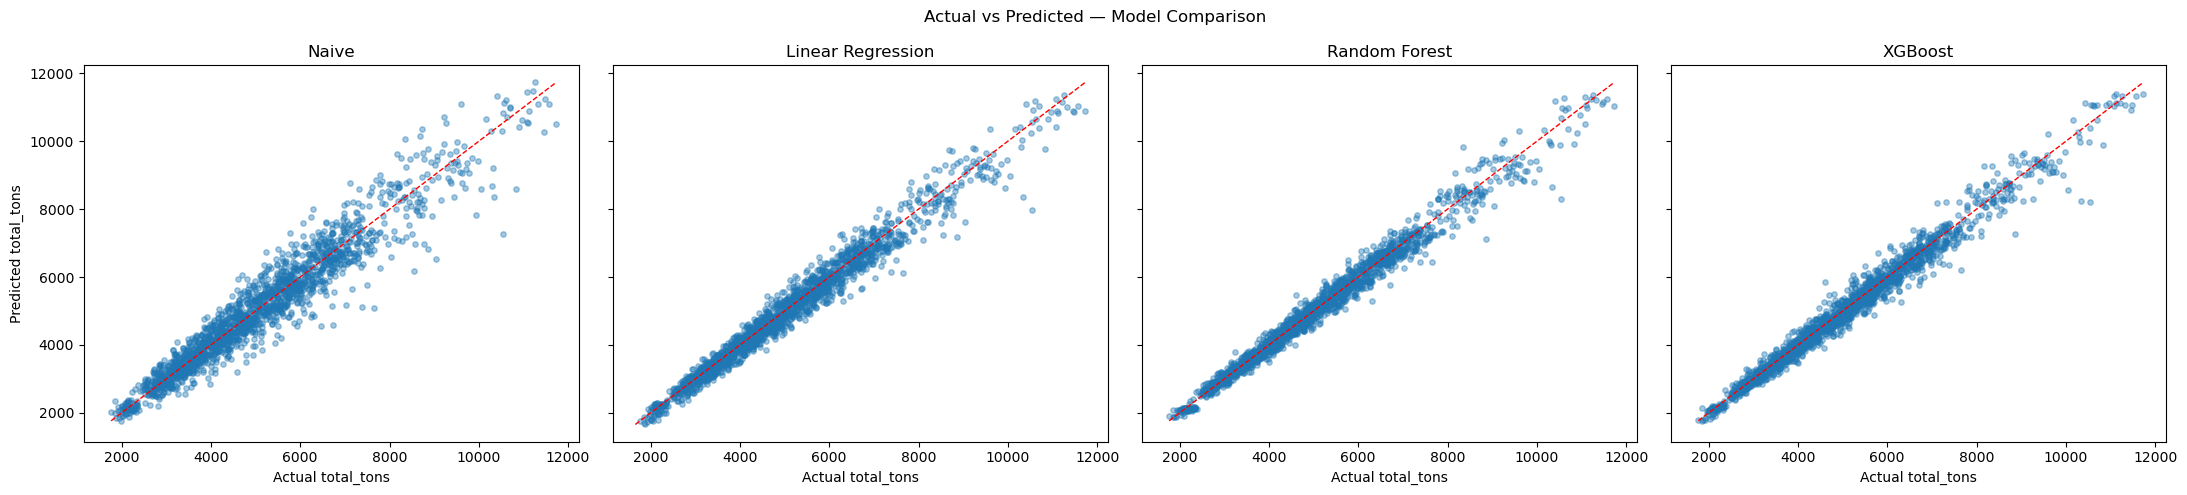

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharex=True, sharey=True)

model_preds = {
    "Naive": naive_preds,
    "Linear Regression": lr_preds,
    "Random Forest": rf_preds,
    "XGBoost": xgb_preds,
}

for ax, (name, preds) in zip(axes, model_preds.items()):
    ax.scatter(y_test, preds, alpha=0.4, s=15)
    lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
    ax.plot(lims, lims, "r--", linewidth=1)  # perfect-prediction reference line
    ax.set_title(name)
    ax.set_xlabel("Actual total_tons")

axes[0].set_ylabel("Predicted total_tons")
plt.suptitle("Actual vs Predicted — Model Comparison")
plt.tight_layout()
plt.savefig(PROCESSED / "actual_vs_predicted_comparison.png", dpi=150)
plt.show()

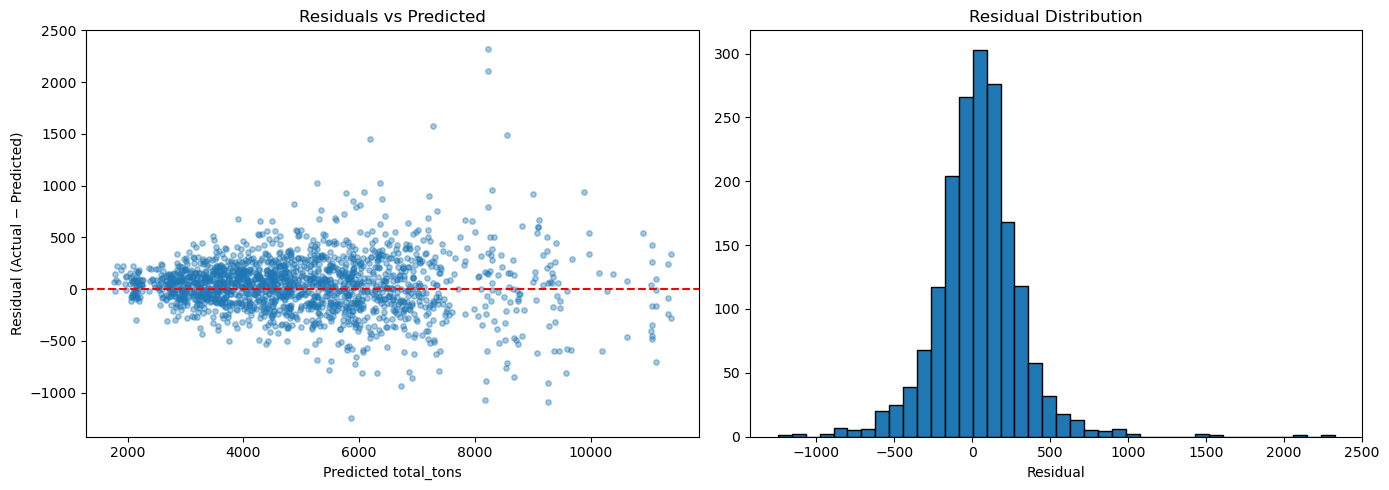

In [13]:
best_preds = xgb_preds  # change to rf_preds if RF won instead
residuals = y_test - best_preds

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(best_preds, residuals, alpha=0.4, s=15)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted total_tons")
axes[0].set_ylabel("Residual (Actual − Predicted)")
axes[0].set_title("Residuals vs Predicted")

axes[1].hist(residuals, bins=40, edgecolor="black")
axes[1].set_xlabel("Residual")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.savefig(PROCESSED / "residual_analysis.png", dpi=150)
plt.show()

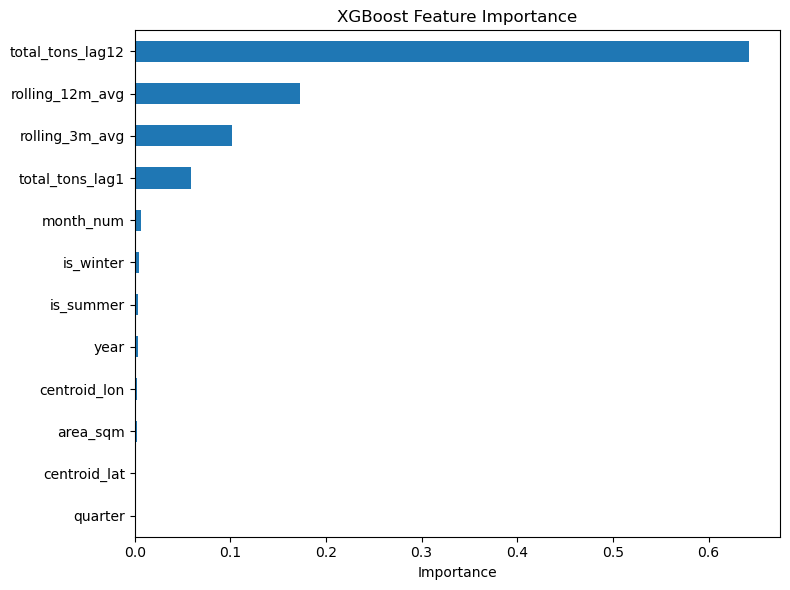

In [14]:
importances = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values()

plt.figure(figsize=(8, 6))
importances.plot(kind="barh")
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(PROCESSED / "feature_importance.png", dpi=150)
plt.show()

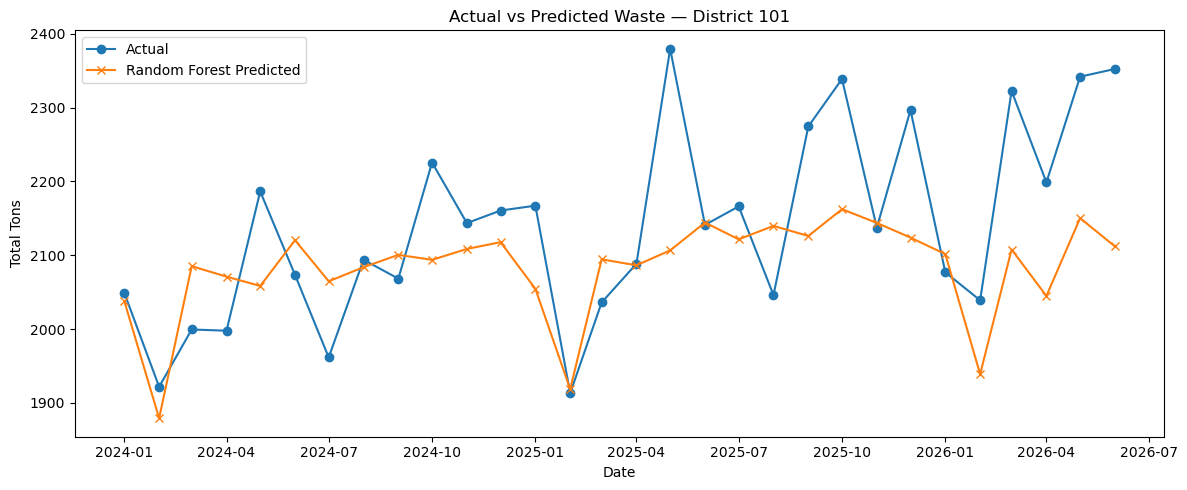

In [20]:
sample_district = test["BoroCd"].unique()[0]  #-----------------------------  pick any district, or hardcode e.g. 201

mask = test["BoroCd"] == sample_district
plt.figure(figsize=(12, 5))
plt.plot(test.loc[mask, "date"], y_test[mask], label="Actual", marker="o")
plt.plot(test.loc[mask, "date"], rf_preds[mask], label="Random Forest Predicted", marker="x")
plt.title(f"Actual vs Predicted Waste — District {sample_district}")
plt.xlabel("Date")
plt.ylabel("Total Tons")
plt.legend()
plt.tight_layout()
plt.savefig(PROCESSED / f"timeseries_district_{sample_district}.png", dpi=150)
plt.show()

In [16]:
# Compare train-set R² vs test-set R² to rule out overfitting
train_preds_rf = rf.predict(X_train)
train_r2 = r2_score(y_train, train_preds_rf)
print(f"Train R²: {train_r2:.3f} | Test R²: {rf_r2:.3f}")

Train R²: 0.981 | Test R²: 0.980


In [25]:
import joblib

MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)
joblib.dump(rf, MODELS_DIR / "best_model_rf.pkl")

features_all = features.copy()
features_all["predicted_tons"] = rf.predict(features_all[feature_cols])

features_all.to_parquet(PROCESSED / "predictions.parquet", index=False)
print("Saved model and predictions.")
print(features_all[["BoroCd", "date", "total_tons", "predicted_tons"]].tail(10))

Saved model and predictions.
       BoroCd       date  total_tons  predicted_tons
24401     503 2025-09-01      7074.4     6844.354123
24402     503 2025-10-01      7098.5     7086.724225
24403     503 2025-11-01      6912.9     7005.650829
24404     503 2025-12-01      7584.3     7146.719579
24405     503 2026-01-01      6062.3     6780.712344
24406     503 2026-02-01      5120.7     5475.996898
24407     503 2026-03-01      7388.1     6454.391223
24408     503 2026-04-01      7330.8     7205.838373
24409     503 2026-05-01      7793.4     7785.517596
24410     503 2026-06-01      7863.1     7316.314810


In [32]:
#FORECASTING     

next_date = features["date"].max() + pd.DateOffset(months=1)
print("Forecasting for:", next_date.date())

# Get each district's most recent 12 months (needed to build lag/rolling features)
last_known = (
    features.sort_values(["BoroCd", "date"])
    .groupby("BoroCd")
    .tail(12)
    .copy()
)

def make_future_row(history_df, boro_cd, next_date):
    hist = history_df[history_df["BoroCd"] == boro_cd].sort_values("date")
    
    row = {}
    row["BoroCd"] = boro_cd
    row["date"] = next_date
    row["year"] = next_date.year
    row["month_num"] = next_date.month
    row["quarter"] = (next_date.month - 1) // 3 + 1
    row["is_summer"] = int(next_date.month in [6, 7, 8])
    row["is_winter"] = int(next_date.month in [12, 1, 2])
    
    row["total_tons_lag1"] = hist["total_tons"].iloc[-1]
    row["total_tons_lag12"] = hist["total_tons"].iloc[-12] if len(hist) >= 12 else hist["total_tons"].iloc[0]
    row["rolling_3m_avg"] = hist["total_tons"].tail(3).mean()
    row["rolling_12m_avg"] = hist["total_tons"].tail(12).mean()
    
    row["area_sqm"] = hist["area_sqm"].iloc[-1]
    row["centroid_lat"] = hist["centroid_lat"].iloc[-1]
    row["centroid_lon"] = hist["centroid_lon"].iloc[-1]
    
    return row

future_rows = [make_future_row(last_known, boro_cd, next_date) for boro_cd in last_known["BoroCd"].unique()]
next_month_forecast = pd.DataFrame(future_rows)

next_month_forecast["predicted_tons"] = rf.predict(next_month_forecast[feature_cols])

print(next_month_forecast.shape)  # should be (59, ...)
next_month_forecast[["BoroCd", "date", "predicted_tons"]].sort_values("predicted_tons", ascending=False).head(10)

Forecasting for: 2026-07-01
(59, 15)


,BoroCd,date,predicted_tons
48,407,2026-07-01,11154.379155
34,311,2026-07-01,9464.657567
53,412,2026-07-01,9389.116680
13,202,2026-07-01,8607.867505
58,503,2026-07-01,7393.248495
54,413,2026-07-01,7321.458157
56,501,2026-07-01,7282.282911
35,312,2026-07-01,7030.534565
7,108,2026-07-01,6996.550981
41,318,2026-07-01,6993.185055


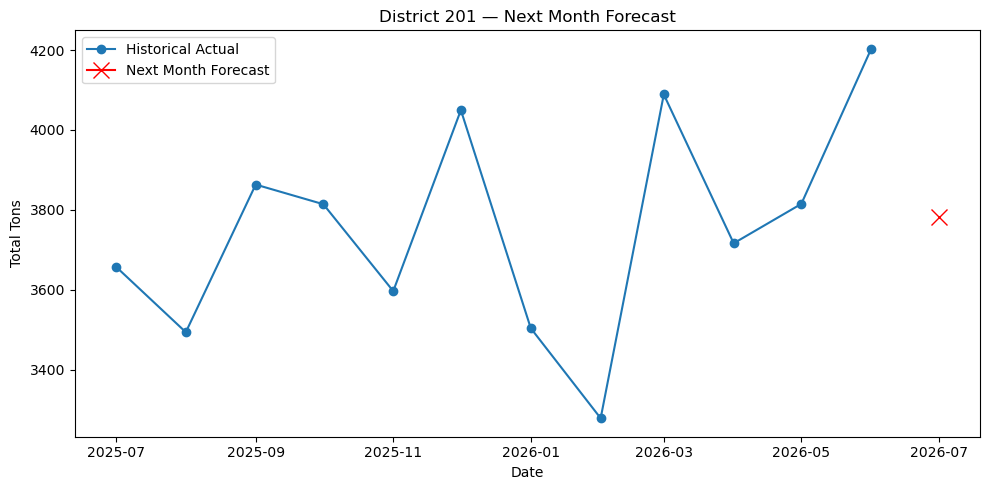

In [33]:
sample = 201
hist_actual = features[features["BoroCd"] == sample].tail(12)
next_pred = next_month_forecast[next_month_forecast["BoroCd"] == sample]

plt.figure(figsize=(10, 5))
plt.plot(hist_actual["date"], hist_actual["total_tons"], label="Historical Actual", marker="o")
plt.plot(next_pred["date"], next_pred["predicted_tons"], label="Next Month Forecast", marker="x", color="red", markersize=12)
plt.title(f"District {sample} — Next Month Forecast")
plt.xlabel("Date")
plt.ylabel("Total Tons")
plt.legend()
plt.tight_layout()
plt.savefig(PROCESSED / f"next_month_forecast_district_{sample}.png", dpi=150)
plt.show()

In [34]:
next_month_forecast.to_parquet(PROCESSED / "next_month_forecast.parquet", index=False)
print(f"Saved next_month_forecast.parquet — {next_month_forecast['BoroCd'].nunique()} districts forecasted for {next_date.date()}")

Saved next_month_forecast.parquet — 59 districts forecasted for 2026-07-01


In [35]:
# Compare each district's forecast to its own recent average — flag anything way off
recent_avg = features.sort_values("date").groupby("BoroCd")["total_tons"].apply(lambda x: x.tail(6).mean())
check = next_month_forecast.merge(recent_avg.rename("recent_6m_avg"), on="BoroCd")
check["pct_diff"] = ((check["predicted_tons"] - check["recent_6m_avg"]) / check["recent_6m_avg"]) * 100

check[["BoroCd", "predicted_tons", "recent_6m_avg", "pct_diff"]].sort_values("pct_diff", key=abs, ascending=False).head(10)

,BoroCd,predicted_tons,recent_6m_avg,pct_diff
35,312,7030.534565,8512.100000,-17.405404
54,413,7321.458157,6329.200000,15.677466
24,301,6400.669722,7511.433333,-14.787639
51,410,5104.252963,4530.616667,12.661329
55,414,4641.904353,4161.166667,11.552954
53,412,9389.116680,8430.800000,11.366853
52,411,4132.460339,3718.116667,11.143913
21,210,3558.871070,3208.216667,10.929885
23,212,5213.265153,4721.616667,10.412715
49,408,4917.063746,4521.216667,8.755322
